<center>  
    <h1> <b> Pokémon Data Analysis </b> </h1>
</center>

<center>
    <img src = "images/Pokemon.jpg" width=800>
</center>

# **1. Introduction :**
This dataset contains information on all 802 Pokemon from all 7 generations of Pokemon. 
The information contained in this dataset include Base Stats, Performance against other types, Height, Weight, Classification, Egg Steps, Experience Points, Abilities, etc. 

Dataset : [The Pokemon Dataset](https://www.kaggle.com/rounakbanik/pokemon)

<br>

# **2. Objective :**
The objective of this project is to perform descriptive analysis to answer some questions like,
- Most prevalent primary types?
- Which type is the strongest overall? Which is the weakest?
- Which type of Pokemon are easiest to catch?
- Which type of Pokemon are effective against which other type of Pokemon?
- Which is the best Pokemon?

also to perform some predictive analysis such as,
- To build a classifier to identify legendary Pokemon.
- Try to build a Pokemon dream team. That is, a team of 6 Pokemon that inflicts the most damage while remaining relatively impervious to any other team of 6 Pokemon.

<br>

# **3. EDA**

**1. Importing modules and the dataset :**

In [1]:
# Set up
import numpy as np
import pandas as pd

In [3]:
# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

**2. Read Dataset**

In [7]:
df = pd.read_csv("pokemon.csv")
display(df.head())

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


**Total of Row and Column**

In [8]:
print(f"The shape of the dataset is: {df.shape}\n")

The shape of the dataset is: (801, 41)



**Type Data**

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    str    
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non-null    fl

#### **Attributes of the dataset :**
- **name :** The English name of the Pokemon
- **japanese_name :** The Original Japanese name of the Pokemon
- **pokedex_number :** The entry number of the Pokemon in the National Pokedex
- **percentage_male :** The percentage that the given Pokemon is male. Blank if Pokemon is genderless.
- **type1 :** The Primary type of the Pokemon
- **type2 :** The Secondary type of the Pokemon
- **classification :** The Classification of the Pokemon as described by the Sun and Moon Pokedex
- **height_m :** Height of the Pokemon in metres
- **weight_kg :** The Weight of the Pokemon in kilograms
- **capture_rate :** Capture rate of the Pokemon
- **baseeggsteps :** The number of steps required to hatch an egg of the Pokemon
- **abilities :** A stringfield list of abilities that Pokemon have
- **experience_growth :** The experience growth of the Pokemon
- **base_happiness :** Base Happiness of the Pokemon
- **against_? :** Eighteen features that denote the amount of damage taken against an attack of a particular type
- **hp :** The base HP of the Pokemon
- **attack :** The base attack of the Pokemon
- **defense :** The base defense of the Pokemon
- **sp_attack :** The base special attack of the Pokemon
- **sp_defense :** The base special defense of the Pokemon
- **speed :** The base speed of the Pokemon
- **generation :** The numbered generation which the Pokemon was first introduced
- **is_legendary :** Denotes if the Pokemon is legendary.

In [10]:
display(df.head())

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


**Description of the attributes of the dataset.**

In [11]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
against_bug,801.0,9.962547e-01,0.597248,0.25,0.5,1.0,1.0,4.0
against_dark,801.0,1.057116e+00,0.438142,0.25,1.0,1.0,1.0,4.0
against_dragon,801.0,9.687890e-01,0.353058,0.00,1.0,1.0,1.0,2.0
against_electric,801.0,1.073970e+00,0.654962,0.00,0.5,1.0,1.0,4.0
against_fairy,801.0,1.068976e+00,0.522167,0.25,1.0,1.0,1.0,4.0
against_fight,801.0,1.065543e+00,0.717251,0.00,0.5,1.0,1.0,4.0
against_fire,801.0,1.135456e+00,0.691853,0.25,0.5,1.0,2.0,4.0
against_flying,801.0,1.192884e+00,0.604488,0.25,1.0,1.0,1.0,4.0
against_ghost,801.0,9.850187e-01,0.558256,0.00,1.0,1.0,1.0,4.0
against_grass,801.0,1.034020e+00,0.788896,0.25,0.5,1.0,1.0,4.0


**Checking for null-values in the dataset.**

In [12]:
df.isna().sum()

abilities              0
against_bug            0
against_dark           0
against_dragon         0
against_electric       0
against_fairy          0
against_fight          0
against_fire           0
against_flying         0
against_ghost          0
against_grass          0
against_ground         0
against_ice            0
against_normal         0
against_poison         0
against_psychic        0
against_rock           0
against_steel          0
against_water          0
attack                 0
base_egg_steps         0
base_happiness         0
base_total             0
capture_rate           0
classfication          0
defense                0
experience_growth      0
height_m              20
hp                     0
japanese_name          0
name                   0
percentage_male       98
pokedex_number         0
sp_attack              0
sp_defense             0
speed                  0
type1                  0
type2                384
weight_kg             20
generation             0


capture_rate, height_m, type2 and weight_kg has null values. <br>
**Note:** null value in percentange male defines that the pokemon is female.

<br>

### **Descriptive Analysis**
### Some Exploratory Data Analysis (EDA) 

#### 1. Univariate Analysis

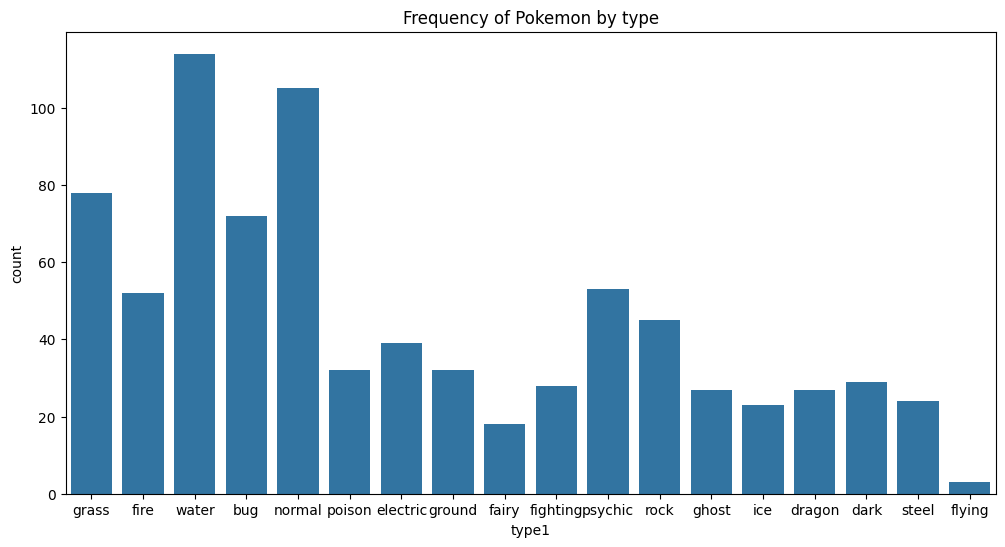

In [16]:
# The frequency of Pokemon by type
plt.figure(figsize=(12, 6))
plt.title("Frequency of Pokemon by type")
sns.countplot(x='type1', data=df)
plt.show()

The frequency of the Water and Normal type is the highest among Pokemons.

<br>

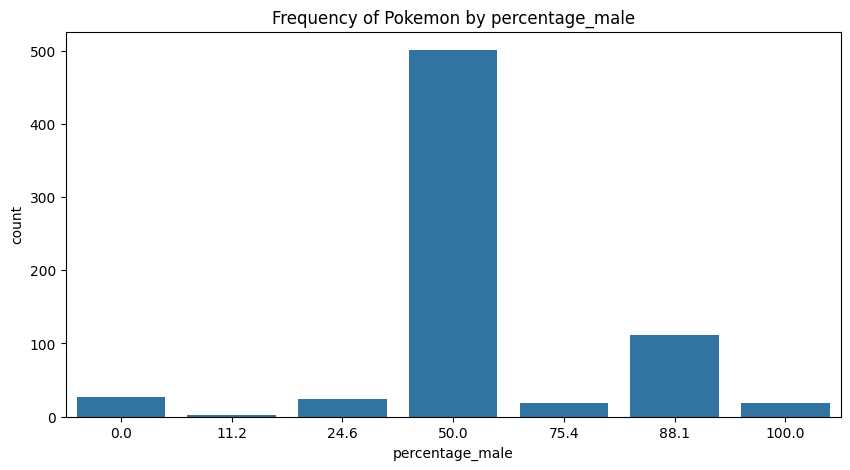

In [17]:
# The frequency of Pokemon's percentage male 
plt.figure(figsize=(10, 5))
plt.title("Frequency of Pokemon by percentage_male")
sns.countplot(x='percentage_male', data=df)
plt.show()

Most of the Pokemon indentify as genderless (non-binary).

<br>

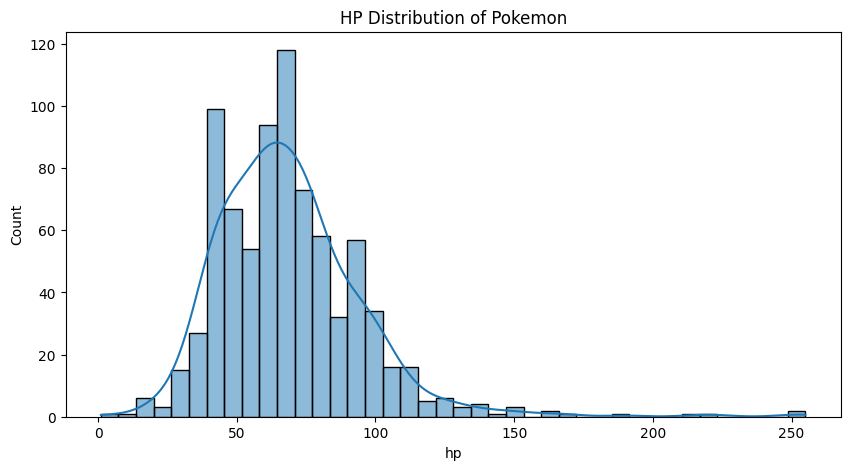

In [18]:
# HP Distribution of Pokemon
plt.figure(figsize=(10, 5))
plt.title("HP Distribution of Pokemon")
sns.histplot(x='hp', data=df, kde=True)
plt.show()

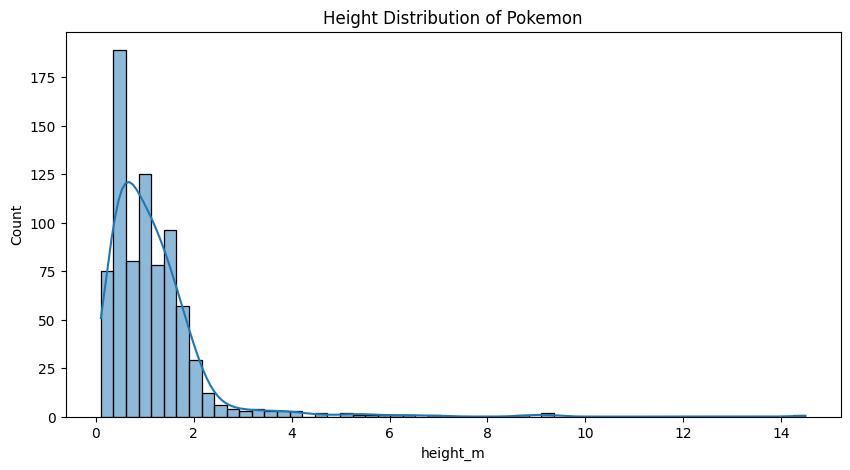

In [21]:
# Height Distribution of Pokemon
plt.figure(figsize=(10, 5))
plt.title("Height Distribution of Pokemon")
sns.histplot(x='height_m', data=df, kde=True)
plt.show()

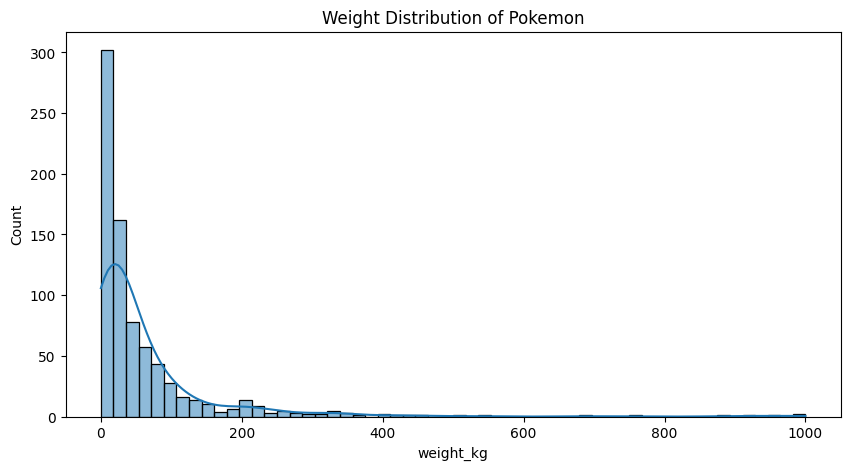

In [22]:
# Weight Distribution of Pokemon
plt.figure(figsize=(10, 5))
plt.title("Weight Distribution of Pokemon")
sns.histplot(x='weight_kg', data=df, kde=True)
plt.show()

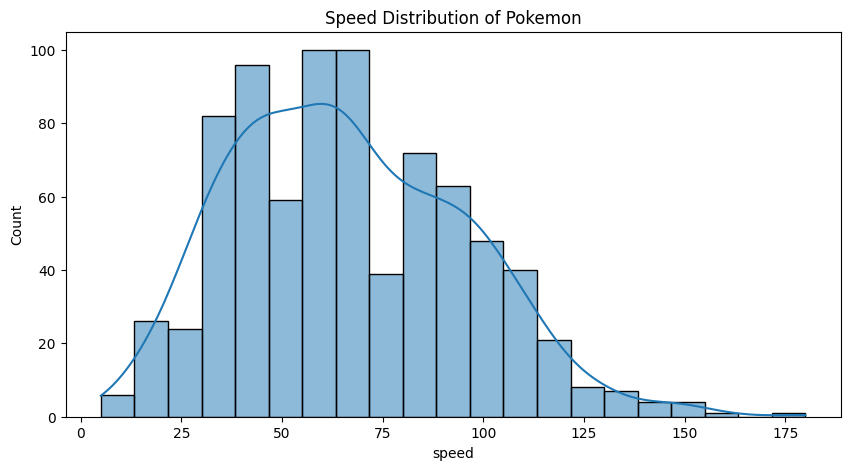

In [23]:
# Speed Distribution of Pokemon
plt.figure(figsize=(10, 5))
plt.title("Speed Distribution of Pokemon")
sns.histplot(x='speed', data=df, kde=True)
plt.show()

<br>

#### 2. Bivariate Analysis

Attack and Defense are the most exciting attributes of a Pokemon, so lets analyze those two.

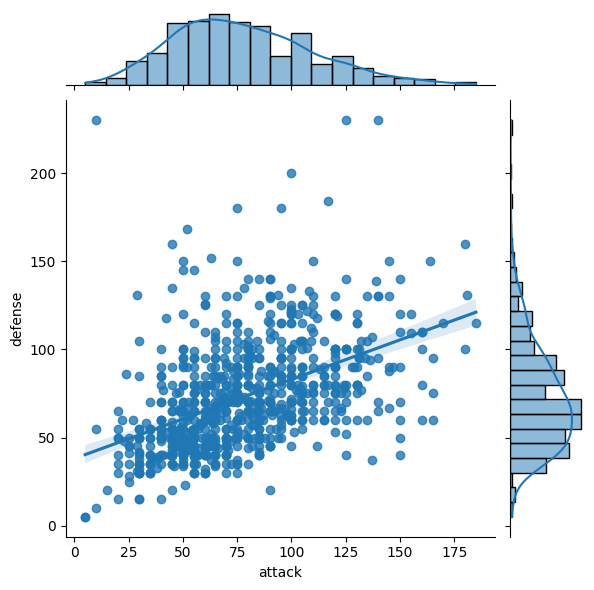

In [24]:
sns.jointplot(x=df['attack'], y=df['defense'], kind='reg')
plt.show()

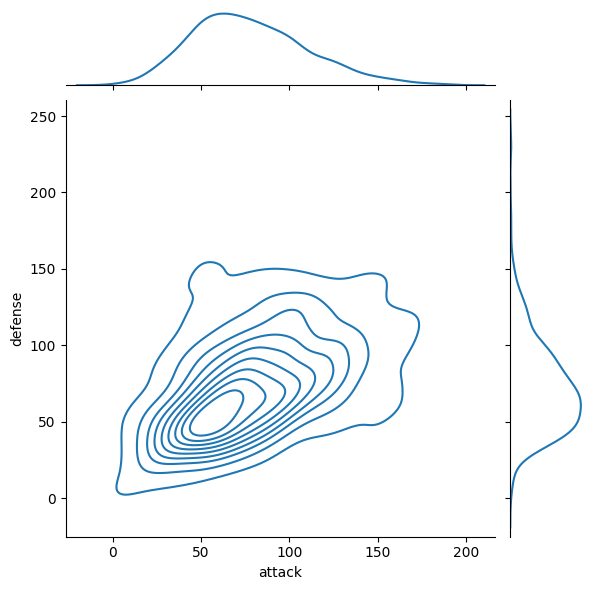

In [25]:
ax = sns.jointplot(x=df['attack'], y=df['defense'], kind='kde')
plt.show()

<br>

Some pair plots are as follows, 

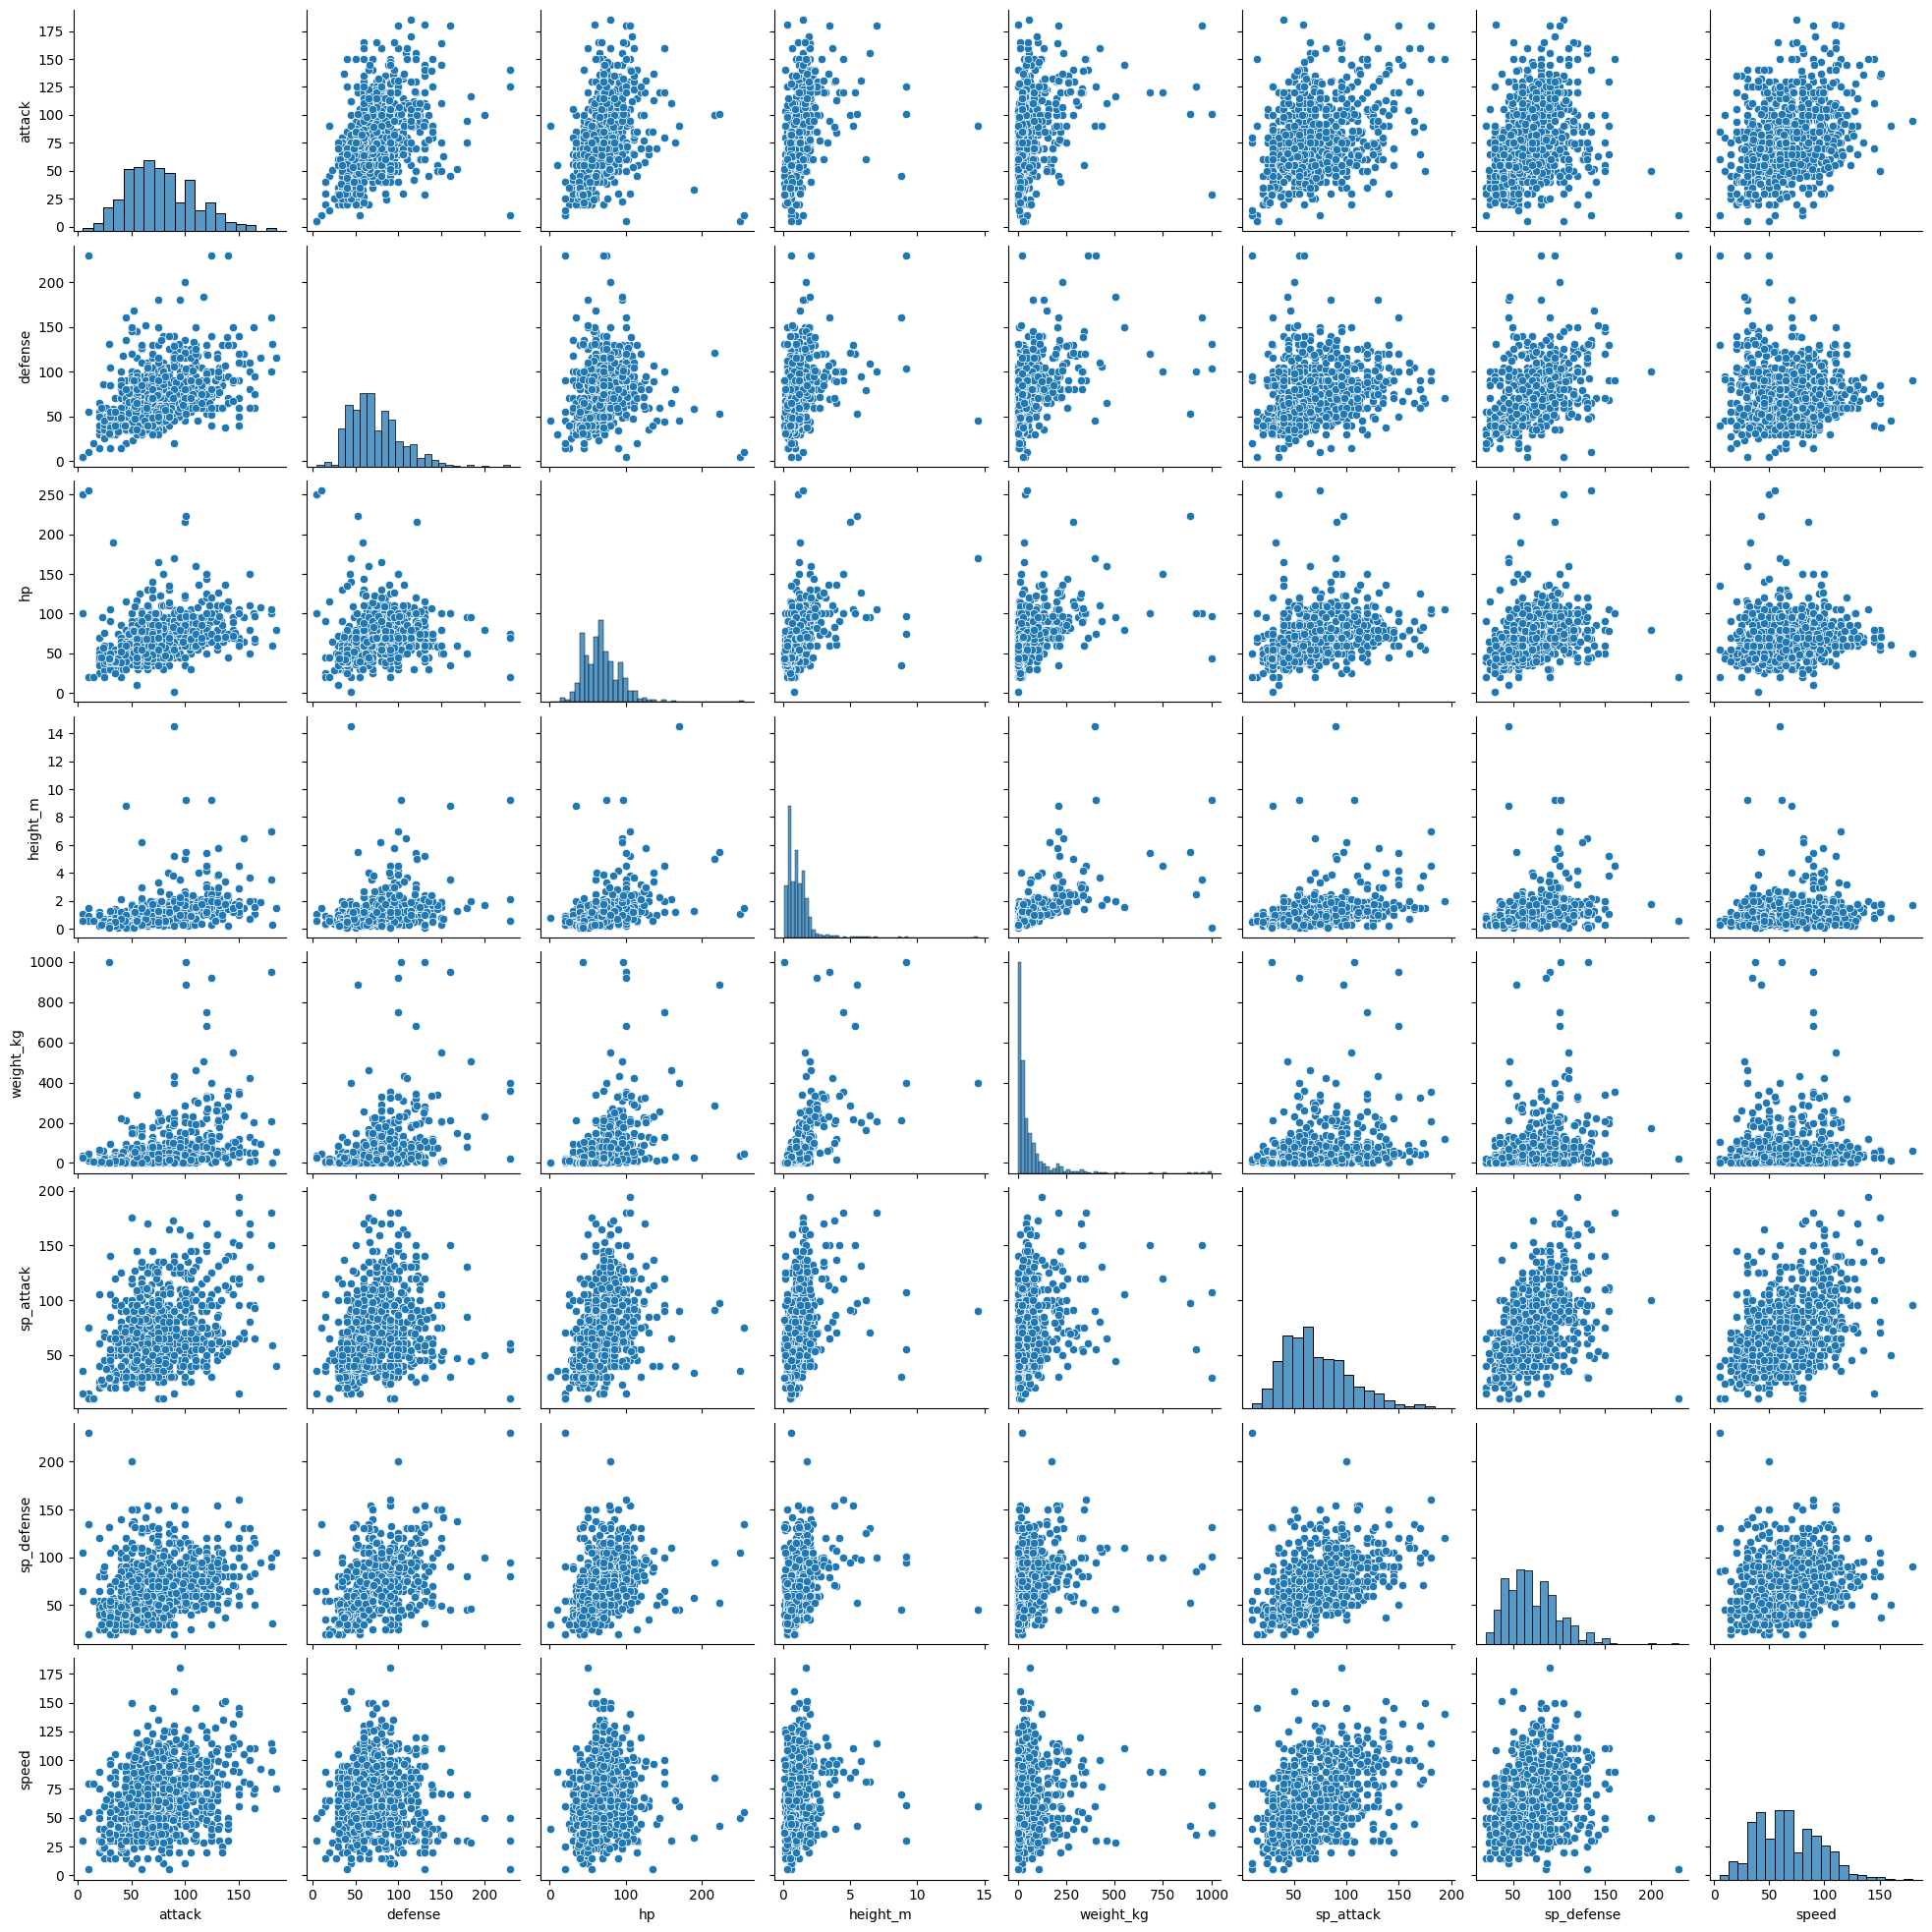

In [26]:
pairs = df[['attack', 'defense', 'hp', 'height_m', 'weight_kg', 'sp_attack', 'sp_defense', 'speed']]
sns.pairplot(pairs)
plt.show()

Clearly, we cannot see much of correlation between the pairs. <br>
Let's confirm the same using a heatmap.

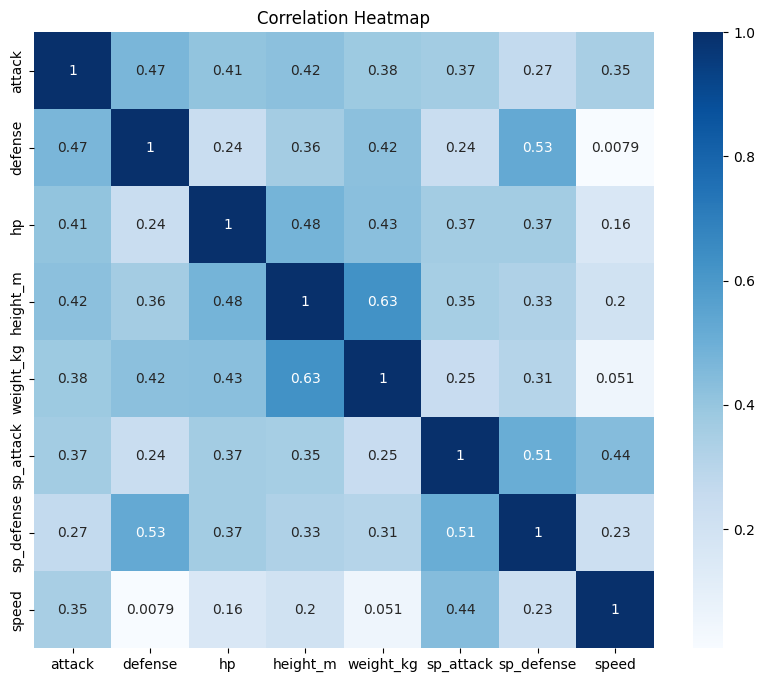

In [27]:
pairs = df[['attack', 'defense', 'hp', 'height_m', 'weight_kg', 'sp_attack', 'sp_defense', 'speed']]
corr = pairs.corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr, annot=True, cmap='Blues')
ax.set_title("Correlation Heatmap")
plt.show()

Hence, it is confirmed that there is little to no correlation between the numerical data in the dataset. <br>
<br>
Let's matrix plot the experience_growth, generation and base_total attributes, to see generational base_total.

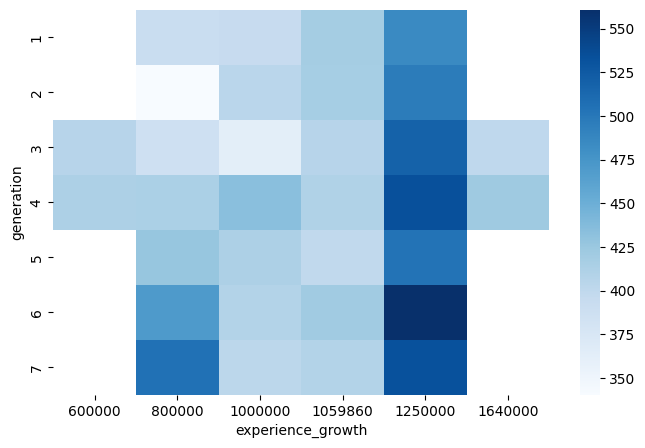

In [28]:
pair = df[['experience_growth', 'generation', 'base_total']]
pair = pair.pivot_table(index='generation', columns='experience_growth', values='base_total')
plt.figure(figsize=(8, 5))
sns.heatmap(pair, cmap='Blues')
plt.show()

That's enough EDA as of now, lets answer some interesting questions.
<br>

# **4. Queries with Descriptive Visualizations**

**How many new Pokemon are there per generation?** <br>
A simple count plot will answer this.

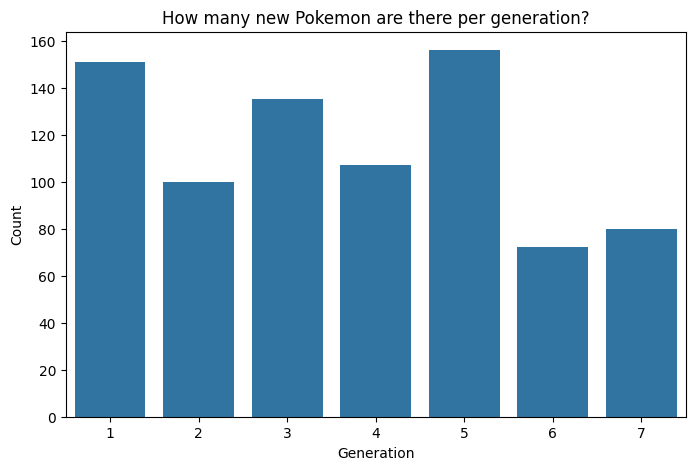

In [30]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x = df['generation'])
ax.set_title("How many new Pokemon are there per generation?")
ax.set(xlabel='Generation', ylabel='Count')
plt.show()

<br>

**What are the most common type combinations?** <br>
A horizontal bar graph will be perfect for this, as we can have more room for labelling.

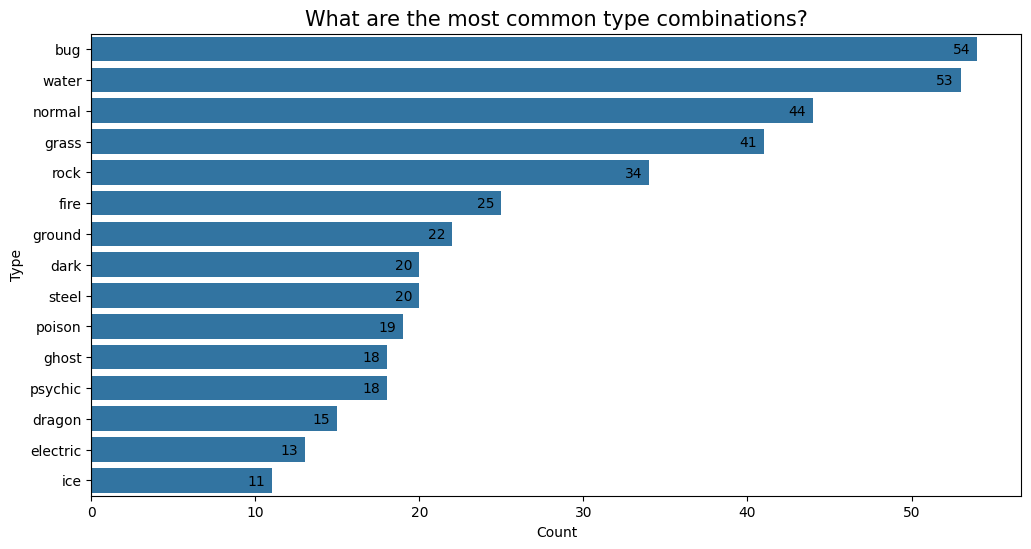

In [38]:
top15_type_counts = df[~df['type2'].isnull()]["type1"].value_counts()[:15]
plt.figure(figsize=(12,6))
ax = sns.barplot(y=top15_type_counts.index, x=top15_type_counts.values, orient='h')
ax.set_title("What are the most common type combinations?", size=15)
ax.set(ylabel="Type", xlabel="Count");

# Annotate value labels to each type
for index, value in enumerate(top15_type_counts): 
    plt.annotate(value, xy=(value-1.5, index+0.15), color='black') 

<br>

**What are the most common type of legendary pokemon?** <br>
A horizontal bar graph should work again.

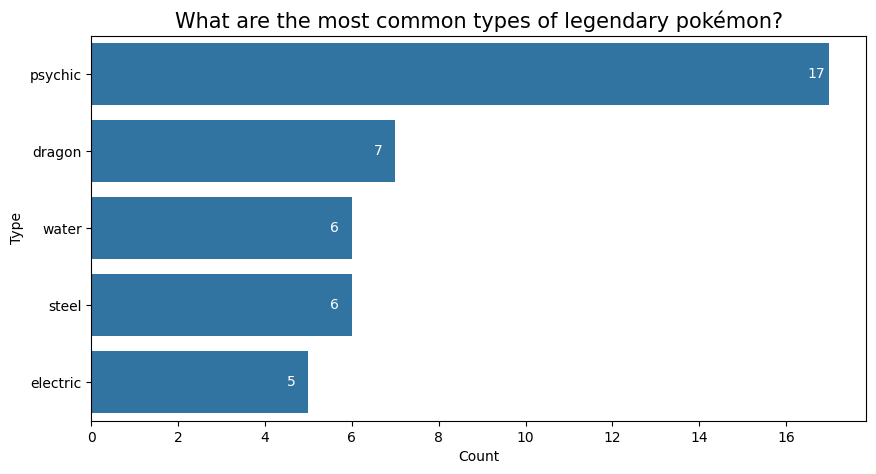

In [46]:
legendary_pokemon = df[df['is_legendary'] == 1]
legendary_pokemon_types_top5 = legendary_pokemon["type1"].value_counts()[:5]
plt.figure(figsize=(10,5))
ax = sns.barplot(y=legendary_pokemon_types_top5.index, x=legendary_pokemon_types_top5.values, orient='h')
ax.set_title("What are the most common types of legendary pokémon?", size=15)
ax.set(xlabel="Count", ylabel="Type")

# Annotate value labels to each type
for index, value in enumerate(legendary_pokemon_types_top5): 
    plt.annotate(value, xy=(value-0.5, index+0.05), color='white')

<br>

**Which type has the easiest Pokemon to catch?** <br>
For this we will use a box plot.

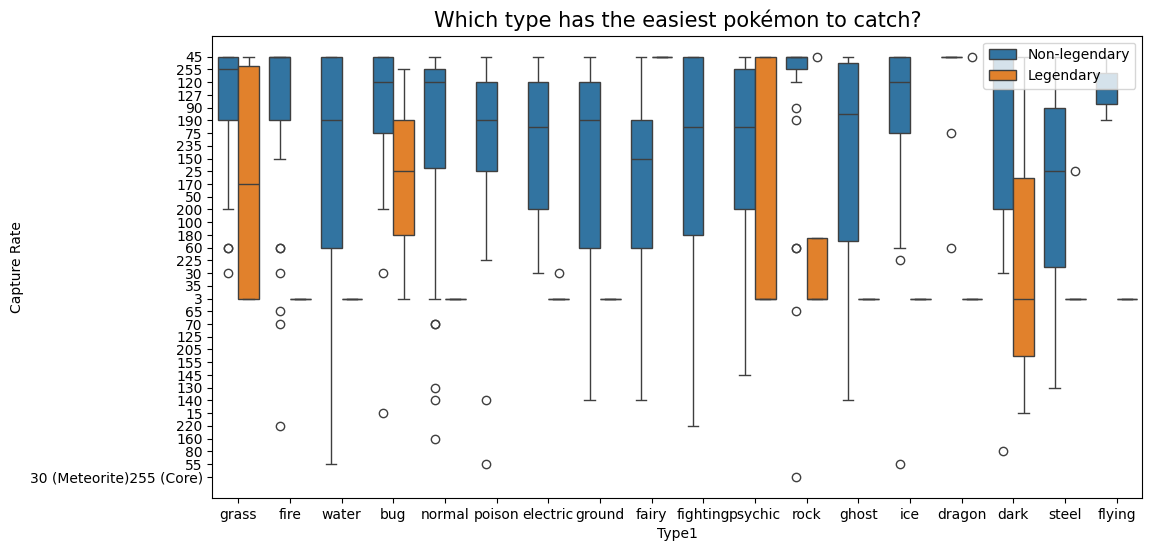

In [50]:
plt.figure(figsize=(12,6))
ax = sns.boxplot(x='type1',y='capture_rate', hue="is_legendary", data = df)
ax.set_title("Which type has the easiest pokémon to catch?", size=15)
ax.set(xlabel="Type1", ylabel="Capture Rate")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Non-legendary", "Legendary"], loc='upper right')
plt.show()

Fairy type has the easiest pokémon to catch, while dragon has the hardest. <br>
The easiest legendary pokémon to catch are of type grass and bug. 
<br>

<br>

**Which is the best generation?** <br>
A box plot is a good choice for this as we will make assumptions based on the distribution of the base total stat.

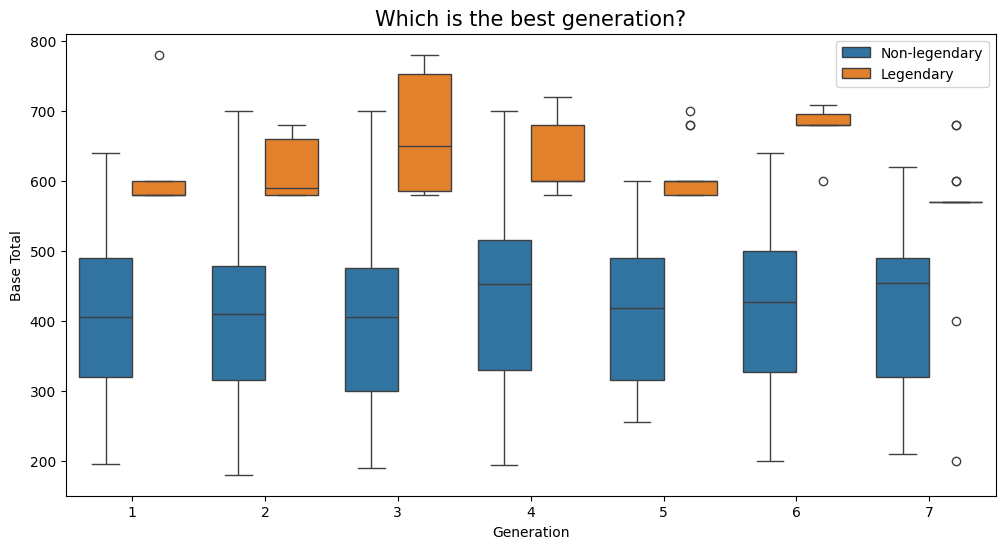

In [52]:
plt.figure(figsize=(12,6))
ax = sns.boxplot(x='generation',y='base_total', hue='is_legendary',data = df)
ax.set_title("Which is the best generation?", size=15)
ax.set(xlabel="Generation", ylabel="Base Total")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Non-legendary", "Legendary"])
plt.show()

<br>

Now, lets analyze my favorite query of 'em all.<br>
**Which is the best Pokemon?** <br>
Let's use a bar plot as per the basic total stat.

In [55]:
top10_pokemon_base_total = df.sort_values(by="base_total", ascending=False).reset_index()[:10]

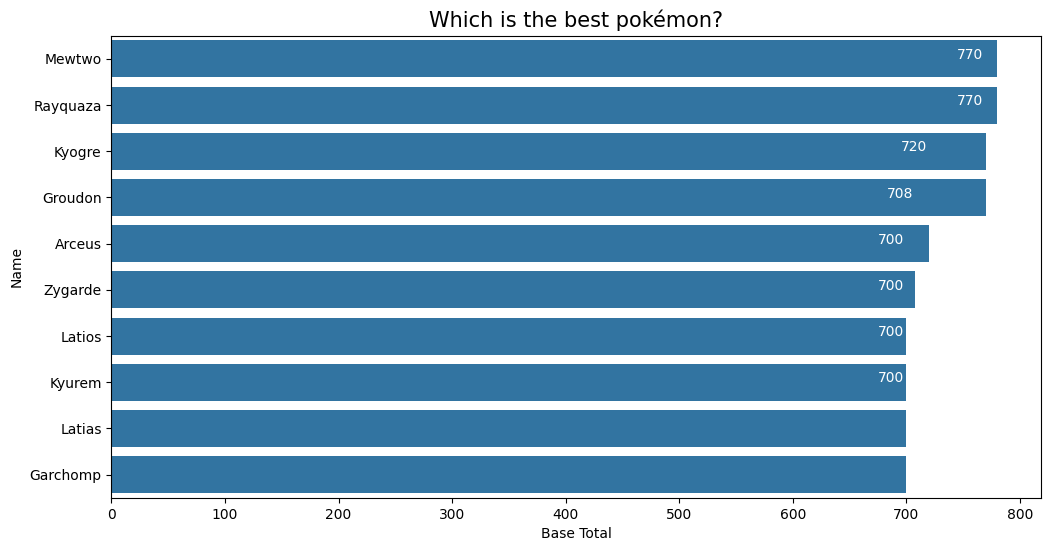

In [59]:
plt.figure(figsize=(12,6))
ax = sns.barplot(y=top10_pokemon_base_total["name"], x=top10_pokemon_base_total["base_total"], orient='h')
ax.set_title("Which is the best pokémon?", size=15)
ax.set(xlabel="Base Total", ylabel="Name")

# Annotate value labels to each pokémon
for index, row in top10_pokemon_base_total.iterrows(): 
    plt.annotate(row["base_total"], xy=(row["base_total"]-25, index-2), color='white') 

We have a tie between **Mewtwo and Rayquaza**. <br>
Let's compare them both using a Radar Chart.

In [60]:
attributes = ["attack", "sp_attack", "defense", "sp_defense", "hp", "speed"]

mewtwo = top10_pokemon_base_total[top10_pokemon_base_total["name"] == "Mewtwo"][attributes].values.tolist()[0]
rayquaza = top10_pokemon_base_total[top10_pokemon_base_total["name"] == "Rayquaza"][attributes].values.tolist()[0]

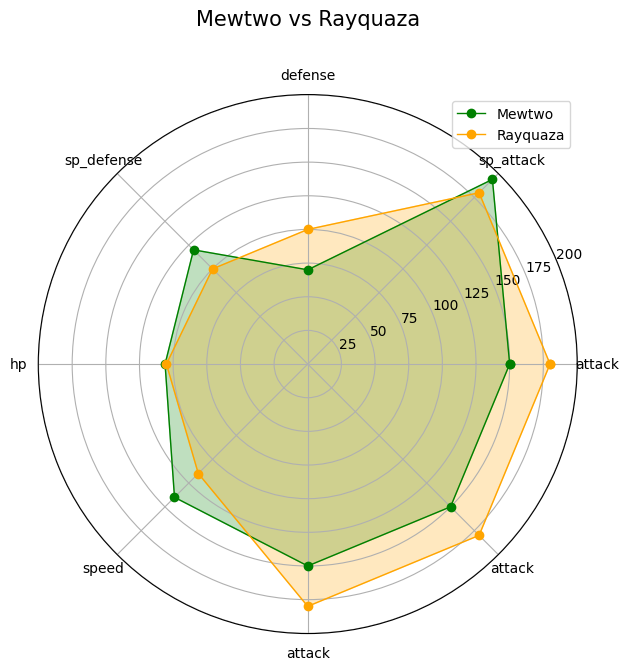

In [63]:
angles=np.linspace(0,2*np.pi,len(attributes), endpoint=False)
angles=np.concatenate((angles,[angles[0]]))
attributes.append(attributes[0])
mewtwo.append(mewtwo[0])
rayquaza.append(rayquaza[0])

fig=plt.figure(figsize=(14,7))
ax=fig.add_subplot(111, polar=True)

# Mewtwo Plot
ax.plot(angles, mewtwo, 'o-', color='g', linewidth=1, label='Mewtwo')
ax.fill(angles, mewtwo, alpha=0.25, color='g')
# Rayquaza Plot
ax.plot(angles,rayquaza, 'o-', color='orange', linewidth=1, label='Rayquaza')
ax.fill(angles, rayquaza, alpha=0.25, color='orange')

ax.set_thetagrids(angles[:-1] * 180/np.pi, attributes[:-1], fontsize=10)
plt.grid(True)
plt.legend(loc="upper right", fontsize=10)
ax.set_title("Mewtwo vs Rayquaza", fontsize=15, pad=50);

Rayquaza has better attack and defense, while Mewtwo is better considering the remaining attributes. <br>
However, my favorite pokemon will always remain **Absol and Greninja**. 

<center>
    <img src = "images/absol.png" width="200"> 
    <img src = "images/greninja.png" width = "400">
</center>

# **5. Predictive Analysis**

### Can we predict whether or not a Pokemon is a legendary?
Before we proceed to write code, lets take a look on the definition of a Legendary Pokemon from the [The Bulbapedia Wiki](https://bulbapedia.bulbagarden.net/wiki/Legendary_Pok%C3%A9mon), legendary Pokemon 
>  _...are a group of incredibly rare and often very powerful Pokémon, generally featured prominently in the legends and myths of the Pokémon world...No explicit criteria defines what makes a Pokémon a Legendary Pokémon. Instead, the only way to identify a Pokémon as belonging to this group is through statements from official media, such as the games or anime._

Let's preprocess our data first, for training.

In [65]:
pokemon_features = ['percentage_male','type1', 'type2', 'height_m', 'weight_kg', 
                     'experience_growth', 'hp', 'attack','base_total',
                     'defense','sp_attack', 'sp_defense', 'speed', 'capture_rate']

# Setting feature and target variables for training
X = pd.DataFrame(df[pokemon_features])
y = df['is_legendary']

Currently, there are three columns with null values. Let's deal with them.

In [66]:
X.isnull().sum()

percentage_male       98
type1                  0
type2                384
height_m              20
weight_kg             20
experience_growth      0
hp                     0
attack                 0
base_total             0
defense                0
sp_attack              0
sp_defense             0
speed                  0
capture_rate           0
dtype: int64

<br>
Only type1 attribute fulfill our needs, hence we set type2 values to be None. <br>
We also do not require the percentage_male attribute as this does not play a role in determining whether the Pokemon is legendary or not.

In [67]:
X['type2'].fillna("None", inplace=True)
X['percentage_male'].fillna(0, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1516\2113510173.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X['type2'].fillna("None", inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1516\2113510173.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an

0      88.1
1      88.1
2      88.1
3      88.1
4      88.1
       ... 
796     0.0
797     0.0
798     0.0
799     0.0
800     0.0
Name: percentage_male, Length: 801, dtype: float64

<br>
For the missing values of height_m and weight_kg we will use SimpleImputer function.

<br>

#### Random Forest Model
We will use a RFModel with a simple pipeline implementation.

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Selecting categorical columns
categorical_cols = [cname for cname in X_train.columns if X_train[cname].dtype == 'object']

# Selecting numerical columns
numerical_cols = [cname for cname in X_train.columns if X_train[cname].dtype in ['int64', 'float64']]

# Imputing the numerical data 
numerical_transform = SimpleImputer(strategy='mean')

# Preprocessing the categorical transform 
categorical_transform = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                        ('onehot', OneHotEncoder(handle_unknown='ignore'))
                                        ])

# Bundling the preprocessing transformers 
preprocessor = ColumnTransformer(transformers = [ ('num', numerical_transform, numerical_cols),
                                                  ('cat', categorical_transform, categorical_cols)])

# Defining the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)

# Creating the final pipeline 
pipeline = Pipeline(steps=[('preprocessorrf', preprocessor), ('modelrf', rf_model)])

In [69]:
# Fitting the model
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessorrf', ...), ('modelrf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [70]:
# Predicting from the model on the test set
pred = pipeline.predict(X_test)

# Indexing the predictions
pred_index = X.index[pred]

# Confusion matrix of the predicted legendary pokemon
pd.crosstab(y_test, pred_index, rownames=['Actual Legendary'], colnames=['Predicted Legendary'])

Predicted Legendary,0,1
Actual Legendary,,
0,145,1
1,3,12


In [71]:
accuracy_rf = accuracy_score(pred, y_test)
print(f'The accuracy of Random Forest Classifier is: {accuracy_rf}')

The accuracy of Random Forest Classifier is: 0.9751552795031055


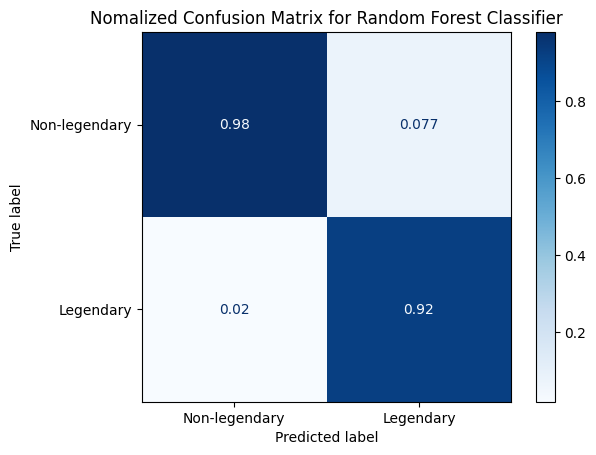

In [80]:
conf_mat_rf = confusion_matrix(pred, y_test)
plot = ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, display_labels=["Non-legendary", "Legendary"], cmap = plt.cm.Blues, normalize = 'pred')
plot.ax_.set_title("Nomalized Confusion Matrix for Random Forest Classifier")
plt.show()

The accuracy in which the legendaries were predicted is 9/15 which is 60%. <br>
While LabelEncoding can increase this percentage, however we will not apply LabelEncoding to this model.

<br>

### Gradient Boosting Model
A gradient booster model will have a high accuracy on this kind of dataset. We will use XGBClassifier from xgboost library.

In [84]:
# Making a copy to avoid spoiling the original transformed feature variables
label_X_train = X_train.copy()
label_X_test = X_test.copy()

# Applying LabelEncoder to each column with categorical data
le = LabelEncoder()
for col in categorical_cols:
    label_X_train[col] = le.fit_transform(X_train[col])
    label_X_test[col] = le.transform(X_test[col])        # We never fit_transform on the feature variables of the test set.

# Convert all columns to numeric (force any remaining non-numeric to NaN)
label_X_train = label_X_train.apply(pd.to_numeric, errors='coerce')
label_X_test = label_X_test.apply(pd.to_numeric, errors='coerce')

# Imputation
imputed_X_train = pd.DataFrame(numerical_transform.fit_transform(label_X_train))
imputed_X_test = pd.DataFrame(numerical_transform.transform(label_X_test))

# Get only the columns that survived imputation
surviving_cols = label_X_train.columns[
    ~label_X_train.isnull().all()
].tolist()

# Put back only the surviving column names
imputed_X_train.columns = surviving_cols
imputed_X_test.columns = surviving_cols

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['type1' 'type2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['type1' 'type2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [86]:
# Creating the XGB Model — move early_stopping_rounds here
XGB_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    eval_metric='logloss',
    early_stopping_rounds=5       # ← move it here
)

# Training the model
XGB_model.fit(
    imputed_X_train, y_train,
    eval_set=[(imputed_X_test, y_test)],
    verbose=False
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",5
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=

In [87]:
# Predicting on the test set
pred = XGB_model.predict(imputed_X_test)
pred_index = X.index[pred]

# Confusion matrix of the predicted legendary pr
pd.crosstab(y_test, pred_index, rownames=['Actual Legendary'], colnames=['Predicted Legendary'])

Predicted Legendary,0,1
Actual Legendary,,
0,145,1
1,5,10


In [88]:
accuracy_xgb = accuracy_score(pred, y_test)
print(f'The accuracy of XGBClassifier is: {accuracy_xgb}')

The accuracy of XGBClassifier is: 0.9627329192546584


The accuracy in which the legendaries were predicted is 12/15 which is 80%. <br>

<br>

# **License**

This project is licensed under the MIT [LICENSE](LICENSE) use it freely for learning, teaching, or building.
```
  _    _ _  ______  _   _ 
 | |  | | |/ / __ \| \ | |
 | |  | | ' / |  | |  \| |
 | |  | |  <| |  | | . ` |
 | |__| | . \ |__| | |\  |
  \____/|_|\_\____/|_| \_|
```
***